# K-Nearest Neighbors (KNN) — Phase 2 (Multi-class MNIST)
This notebook implements a **custom KNN classifier** for **multi-class digit recognition (0–9)** using MNIST feature representations from `preprocessing2.py`.

**Idea:** KNN is a *lazy* learner — “training” stores the data; prediction classifies a point by looking at its $k$ nearest neighbors in the training set.

**What you’ll do in this notebook**
- Load pre-extracted features (PCA by default) for Train/Val/Test
- Implement KNN distance computation + weighted voting
- Select a good $k$ using an elbow curve on the validation set
- Evaluate using accuracy, confusion matrix, and macro-F1 (multi-class)
- (Optional) repeat using CNN (VGG16) embeddings

## 1) Load Preprocessed Data
We load MNIST **features + labels** using `preprocess(...)` from `preprocessing2.py`. In Phase 2, features can be:
- **PCA** (`feature_method="pca"`) → loads `mnist_pca50_features.npz`
- **HOG / HOG+PCA** → loads `mnist_hog_features.npz` / `mnist_hog_pca_features.npz`
- **CNN embeddings** (`feature_method="cnn"`) → loads `mnist_vgg16_features.npz`
- **Flatten** → raw pixels flattened to 784 dims

**Outputs returned**
- `X_train, y_train` : training features and digit labels (0–9)
- `X_val, y_val` : validation split used for tuning (e.g., choosing $k$)
- `X_test, y_test` : final evaluation split
- `weights` : class weights (not used by our KNN implementation here)

In [45]:
from preprocessing2 import preprocess 
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca")


## 2) Model Definition (Custom KNN)
This cell defines a **from-scratch KNN** classifier with:
- Distance metric: currently **Euclidean** (vectorized)
- Voting: **uniform** vote or **distance-weighted** vote (inverse-distance)

**Vectorized Euclidean distance:** for test matrix $X$ and train matrix $T$, we use
$$\|x-t\|^2 = \|x\|^2 + \|t\|^2 - 2x\cdot t$$
to compute all pairwise distances efficiently (no explicit nested loops).

**Prediction logic:**
1. Find indices of the $k$ nearest training points for each sample
2. Aggregate votes per class label (uniform or weighted)
3. Pick the label with the largest vote

In [46]:
import numpy as np
class KNN:
    def __init__(self, k=3,  metric='euclidean', weights='uniform'):
        self.k = k
        self.metric = metric
        self.weights = weights
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    def _compute_distances(self, X):
        """Compute distances from all test points to all training points at once."""
        if self.metric == 'euclidean':
            a2 = np.sum(X ** 2, axis=1, keepdims=True)           
            b2 = np.sum(self.X_train ** 2, axis=1, keepdims=True) 
            dists = np.sqrt(np.maximum(a2 + b2.T - 2 * X @ self.X_train.T, 0))
        
        elif self.metric == 'manhattan':

                dists = np.sum(
                np.abs(X[:, np.newaxis] - self.X_train),
                axis=2
            )    

        else:
            raise ValueError(f"Metric '{self.metric}' not supported in vectorized mode")

        return dists 
         
            
    def predict(self, X):
        X = np.array(X)
        dists = self._compute_distances(X)          # (n_test, n_train)
        k_idx = np.argsort(dists, axis=1)[:, :self.k]  # (n_test, k)
        #k_idx = np.argpartition(dists, self.k, axis=1)[:, :self.k]  # (n_test, k)


        predictions = []
        for i, neighbors in enumerate(k_idx):
            labels = self.y_train[neighbors]
            if self.weights == 'uniform':
                weights = np.ones(self.k)
            else:
                weights = 1 / (dists[i, neighbors] + 1e-9)

            
            label_counts = {}
            for label, w in zip(labels, weights):
                label_counts[label] = label_counts.get(label, 0) + w
            predicted_label = max(label_counts, key=label_counts.get)
            predictions.append(predicted_label)

        return np.array(predictions)


## 3) Training (Fit)
KNN has no learned parameters like regression models. `fit(...)` here simply stores:
- `X_train` (feature vectors)
- `y_train` (integer class labels 0–9)

**Important:** since KNN is instance-based, the main “hyperparameter” affecting performance is **$k$** (and the voting scheme / distance metric).

In [47]:
#create an instance of the KNN class
knn = KNN(k=3, metric="euclidean", weights="distance")
#fit the model to the training data
knn.fit(X_train, y_train)



### knn using manhattan


In [10]:
subset_size = int(len(X_train) * 0.05) #3000 from 60,000
indices = np.random.choice(len(X_train), subset_size, replace=False)

X_train_sub = X_train[indices]
y_train_sub = y_train[indices]
knn = KNN(k=3, metric="manhattan", weights="distance")
knn.fit(X_train_sub, y_train_sub)

## 4) Elbow Method Helper (Tune $k$)
This helper function evaluates several candidate values of $k$ on the **validation** set and plots the validation **error**:
$$\text{error}(k) = 1 - \text{accuracy}(k)$$

**What it does per $k$**
- Sets `knn.k = k`
- Predicts `y_pred` on `X_val`
- Computes accuracy and stores error
- Plots error vs. $k$ (the “elbow curve”)


In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_elbow_knn_manual(knn, X_val, y_val, k_range):
    errors = []

    for k in k_range:
        print(f"Running k = {k} ...")

        knn.k = k  # set k

        y_pred = knn.predict(X_val)

        acc = np.mean(y_pred == y_val)  
        error = 1 - acc

        errors.append(error)

        print(f"k={k}, Accuracy={acc:.4f}, Error={error:.4f}")

    # Plot
    plt.figure()
    plt.plot(k_range, errors, marker='o')
    plt.xlabel("k")
    plt.ylabel("Error")
    plt.title("Elbow Method (Manual KNN)")
    plt.show()

    return errors

## 5) Choose $k$ Using the Elbow Curve
We try a small range of odd $k$ values to avoid ties and to keep inference time reasonable.

**How to interpret the plot**
- Lower error is better
- Look for the point after which improvements become small (the “elbow”)

**Recommended practice**
After you decide on the best $k$, assign it back to the model (e.g., `knn.k = best_k`) before running the final evaluations below.

Running k = 1 ...
k=1, Accuracy=0.9793, Error=0.0207
Running k = 3 ...
k=3, Accuracy=0.9808, Error=0.0192
Running k = 5 ...
k=5, Accuracy=0.9805, Error=0.0195
Running k = 7 ...
k=7, Accuracy=0.9813, Error=0.0187
Running k = 9 ...
k=9, Accuracy=0.9808, Error=0.0192
Running k = 11 ...
k=11, Accuracy=0.9802, Error=0.0198
Running k = 13 ...
k=13, Accuracy=0.9795, Error=0.0205


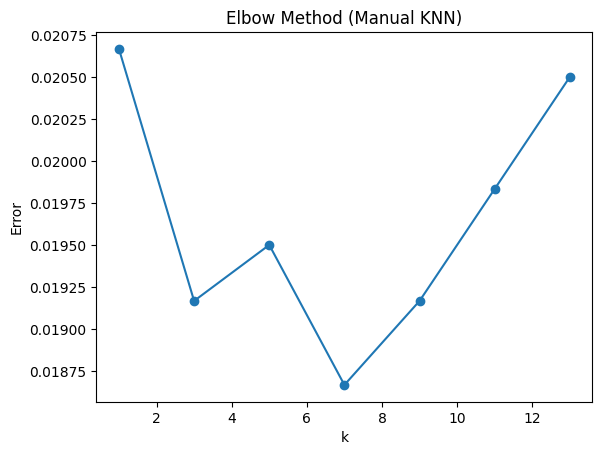

Done running elbow method for KNN.
Errors for KNN: [np.float64(0.020666666666666722), np.float64(0.019166666666666665), np.float64(0.019499999999999962), np.float64(0.01866666666666672), np.float64(0.019166666666666665), np.float64(0.01983333333333337), np.float64(0.020499999999999963)]


In [31]:
k_values = range(1, 15, 2)

errors = plot_elbow_knn_manual(knn, X_val, y_val, k_values)
print("Done running elbow method for KNN.")
print("Errors for KNN:", errors)

## 6) Evaluation Helper (Multi-class Metrics)
This function evaluates a **10-class** classifier (digits 0–9) and prints:
- Overall **accuracy**
- **Confusion matrix** (10×10)
- Per-class **precision / recall / F1**
- **Macro-F1** (simple average F1 across classes)

**Assumptions**
- `y` and predictions are integer labels in the range 0–9
- All 10 classes are considered (`n_classes = 10`)

In [49]:
def evaluate_model(X, y, model, dataset_name="Validation"):
    """
    Evaluate multiclass model (digits 0-9)
    """

    y_pred = model.predict(X)
    y_true = y

    n_classes = 10  

    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    accuracy = np.trace(cm) / np.sum(cm)

    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision[i] = tp / (tp + fp + 1e-9)
        recall[i]    = tp / (tp + fn + 1e-9)
        f1[i]        = 2 * precision[i] * recall[i] / (precision[i] + recall[i] + 1e-9)

    macro_f1 = np.mean(f1)

    print(f"\n--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(f"{'Class':<10}{'Precision':>10}{'Recall':>10}{'F1-score':>12}")

    for i in range(n_classes):
        print(f"{i:<10}{precision[i]:>10.2f}{recall[i]:>10.2f}{f1[i]:>12.2f}")

## 7) Overfitting/Underfitting Diagnosis (Learning Curves)
We plot **training vs validation accuracy** while increasing how much training data we use.

**Interpretation**
- **Overfitting**: training accuracy is high but validation accuracy is much lower
- **Underfitting**: both accuracies are low
- **Good fit**: both are high and close

> KNN can be expensive for large train sizes, so we evaluate accuracy on small (fixed) samples for speed.

Training on 800 samples (10%)...
Training on 2600 samples (32%)...
Training on 4400 samples (55%)...
Training on 6200 samples (77%)...
Training on 8000 samples (100%)...


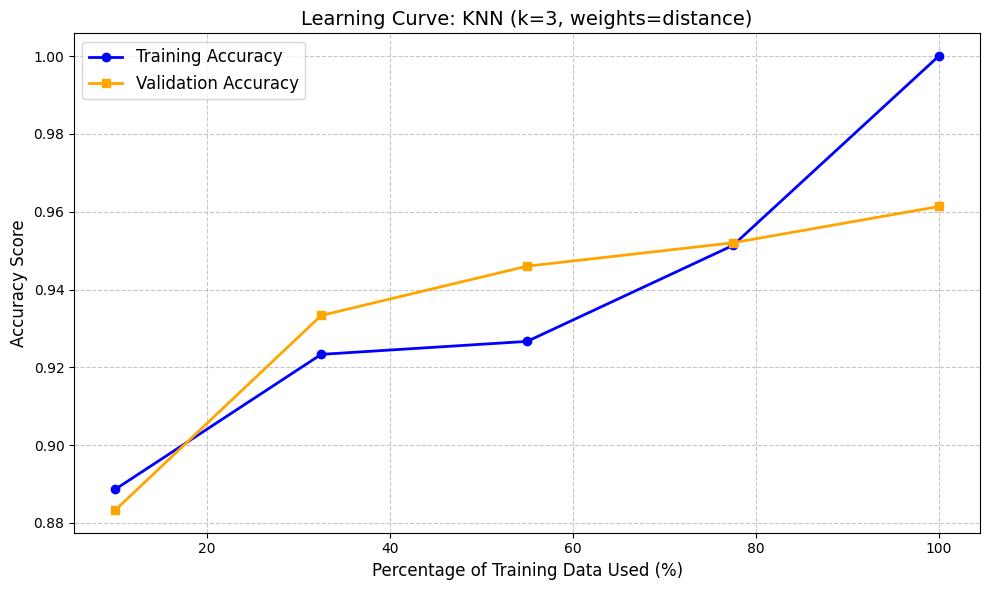

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing2 import custom_accuracy_score

# Simple learning curve for KNN
train_fractions = np.linspace(0.1, 1.0, 5)
train_scores = []
val_scores = []

# KNN is expensive on the full 54k train set, so we cap it for learning curves
max_train_samples = 8000
train_eval_size = 1500
val_eval_size = 1500

np.random.seed(42)
total_train_samples = len(X_train)
pool_size = min(max_train_samples, total_train_samples)
pool_idx = np.random.permutation(total_train_samples)[:pool_size]

X_pool = X_train[pool_idx]
y_pool = y_train[pool_idx]

# Small validation sample for speed
X_val_curve = X_val[: min(val_eval_size, len(X_val))]
y_val_curve = y_val[: min(val_eval_size, len(y_val))]

for fraction in train_fractions:
    subset_size = max(1, int(pool_size * fraction))
    print(f"Training on {subset_size} samples ({int(fraction * 100)}%)...")

    # Fit on subset
    X_fit = X_pool[:subset_size]
    y_fit = y_pool[:subset_size]

    curve_model = KNN(k=knn.k, metric=knn.metric, weights=knn.weights)
    curve_model.fit(X_fit, y_fit)

    X_train_eval = X_pool[subset_size : subset_size + train_eval_size]
    y_train_eval = y_pool[subset_size : subset_size + train_eval_size]
    if len(X_train_eval) == 0:
        X_train_eval = X_fit[: min(train_eval_size, subset_size)]
        y_train_eval = y_fit[: min(train_eval_size, subset_size)]

    train_preds = curve_model.predict(X_train_eval)
    val_preds = curve_model.predict(X_val_curve)

    train_scores.append(custom_accuracy_score(y_train_eval, train_preds))
    val_scores.append(custom_accuracy_score(y_val_curve, val_preds))

plt.figure(figsize=(10, 6))
plt.plot(train_fractions * 100, train_scores, label="Training Accuracy", color="blue", marker="o", linewidth=2)
plt.plot(train_fractions * 100, val_scores, label="Validation Accuracy", color="orange", marker="s", linewidth=2)

plt.title(f"Learning Curve: KNN (k={knn.k}, weights={knn.weights})", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 8) Cross-Validation / Grid Search (Optional)
This section performs a simple **grid search** over:
- Feature method: `cnn`, `pca`, `flatten`, `hog`
- $k$ values (neighbors)
- Voting weights: `uniform` vs `distance`

**Procedure**
- For each feature method, reload the corresponding features
- Build 3 folds from the training set indices
- Train a fresh KNN on each fold and score on the held-out fold
- Average the **macro-F1** across folds
- Track the best hyperparameters

**Note:** this cell expects helper functions `k_fold_indices` and `custom_macro_f1_score` to be available (they exist in `preprocessing2.py`). If you run into a `NameError`, import them before running the cell.

In [ ]:
#cross validate on the validation set
import numpy as np

# Different feature extraction methods
feature_methods = ["cnn", "pca", "flatten","hog"]

# Hyperparameters to search
param_grid = {
    "k": [3, 5],
    "metric": ["euclidean"],
    "weights": ["uniform", "distance"]
}

best_f1_score = 0
best_params = {}

total_runs = (
    len(feature_methods)
    * len(param_grid["k"])
    * len(param_grid["metric"])
    * len(param_grid["weights"])
)

current_run = 1

for feature_method in feature_methods:

    # Load and preprocess data
    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=feature_method,
        n_pca=50
    )

    # Create folds
    folds = k_fold_indices(X_train, k=3)

    # Hyperparameter search
    for k in param_grid["k"]:
        for metric in param_grid["metric"]:
            for weights in param_grid["weights"]:

                print(
                    f"--- Run {current_run}/{total_runs} | "
                    f"Feature:{feature_method} | "
                    f"k:{k} | metric:{metric} | weights:{weights} ---"
                )

                fold_f1_scores = []

                for train_idx, val_idx in folds:

                    X_fold_train = X_train[train_idx]
                    y_fold_train = y_train[train_idx]

                    X_fold_val = X_train[val_idx]
                    y_fold_val = y_train[val_idx]

                    # Create fresh KNN model
                    cv_model = KNN(
                        k=k,
                        metric=metric,
                        weights=weights
                    )

                    cv_model.fit(X_fold_train, y_fold_train)

                    preds = cv_model.predict(X_fold_val)

                    fold_f1 = custom_macro_f1_score(
                        y_fold_val,
                        preds,
                        n_classes=10
                    )

                    fold_f1_scores.append(fold_f1)

                avg_f1 = np.mean(fold_f1_scores)

                print(f"    -> 3-Fold Average Macro F1: {avg_f1:.4f}\n")

                # Save best parameters
                if avg_f1 > best_f1_score:

                    best_f1_score = avg_f1

                    best_params = {
                        "feature_method": feature_method,
                        "k": k,
                        "metric": metric,
                        "weights": weights
                    }

                current_run += 1

print("=" * 50)
print("GRID SEARCH COMPLETE")
print("=" * 50)

print(f"Best CV Macro F1: {best_f1_score:.4f}")
print(f"Best Parameters: {best_params}")

## 9) Evaluation on the Validation Set
We evaluate the current KNN configuration on the **validation split**.

**Use this to**
- Compare candidate settings (e.g., different $k$ / feature method)
- Inspect which digits are being confused (via the confusion matrix)
- Check whether errors are class-specific (macro-F1 is sensitive to that)

In [51]:
evaluate_model(X_val, y_val, knn, dataset_name="Validation FULL")


--- Validation FULL Results ---
Accuracy  : 0.9808
Macro F1  : 0.9806

Confusion Matrix:
[[581   0   2   1   0   0   0   0   1   2]
 [  0 627   1   1   0   0   1   0   0   0]
 [  1   1 594   0   0   0   0   3   1   0]
 [  0   0   2 613   0   6   0   0   6   0]
 [  0   6   0   0 577   0   0   1   0  11]
 [  0   1   0   9   1 527   6   0   4   1]
 [  0   0   0   0   0   0 571   0   0   0]
 [  0   3   1   1   1   0   0 656   0   6]
 [  0   2   1   2   1   5   2   0 580   4]
 [  0   0   0   4   7   4   0   2   0 559]]

Classification Report:
Class      Precision    Recall    F1-score
0               1.00      0.99        0.99
1               0.98      1.00        0.99
2               0.99      0.99        0.99
3               0.97      0.98        0.97
4               0.98      0.97        0.98
5               0.97      0.96        0.97
6               0.98      1.00        0.99
7               0.99      0.98        0.99
8               0.98      0.97        0.98
9               0.96     

## 10) Evaluation on the Test Set
Once you’re happy with your chosen hyperparameters (especially $k$), evaluate on the **test split** to estimate generalization performance.

**Important:** avoid tuning based on test performance. Use validation for selection, then report test results once.

In [52]:
evaluate_model(X_test, y_test, knn, dataset_name="Test FULL")


--- Test FULL Results ---
Accuracy  : 0.9755
Macro F1  : 0.9753

Confusion Matrix:
[[ 975    1    1    0    0    1    1    1    0    0]
 [   0 1131    3    0    0    0    0    0    0    1]
 [   5    1 1006    2    1    0    2   14    1    0]
 [   0    0    3  973    1   13    0    7   10    3]
 [   1    1    0    0  957    0    2    1    1   19]
 [   3    0    0   11    2  859    8    1    5    3]
 [   5    2    0    0    3    2  946    0    0    0]
 [   0   13    6    2    3    0    0  996    0    8]
 [   4    0    3   13    4    3    5    3  936    3]
 [   5    3    1    6    7    4    1    3    3  976]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.98      0.99        0.99
1               0.98      1.00        0.99
2               0.98      0.97        0.98
3               0.97      0.96        0.96
4               0.98      0.97        0.98
5               0.97      0.96        0.97
6               0.98      0.99        0.98
7               0

## 11) Experiment: KNN on CNN (VGG16) Features
This section reruns KNN using **CNN embeddings** instead of PCA/handcrafted features.

**What changes?**
- `preprocess(feature_method="cnn")` loads precomputed VGG16 feature vectors (one vector per image)
- KNN then runs in that embedding space

**Why try this?**
CNN embeddings often separate digit classes better than raw pixels, which can improve KNN accuracy without changing the classifier itself.

### Steps in the next cell
1. Load CNN features for train/val/test
2. Re-create a fresh KNN instance (so parameters are clean)
3. Fit on training features
4. Evaluate on validation then test using the same `evaluate_model(...)` helper

In [53]:
from preprocessing2 import preprocess 
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="cnn")

knn = KNN(k=3, metric="euclidean", weights="distance")
#fit the model to the training data
knn.fit(X_train, y_train)

#validation set evaluation
evaluate_model(X_val, y_val, knn, dataset_name="Validation FULL")

##test set evaluation
evaluate_model(X_test, y_test, knn, dataset_name="Test FULL")

CNN Features Loaded: Train=54000, Val=6000, Test=10000

--- Validation FULL Results ---
Accuracy  : 0.9238
Macro F1  : 0.9228

Confusion Matrix:
[[577   1   1   0   0   1   5   0   0   2]
 [  0 624   0   0   2   0   0   4   0   0]
 [  1   3 497  16   1  14   7  10  32  19]
 [  0   0   6 582   0  29   2   0   5   3]
 [  0  12   7   0 556   0   2   4   4  10]
 [  0   0  12  58   1 453  14   1   9   1]
 [  2   4   1   1   2   4 551   0   1   5]
 [  0   8  15   2  17   2   0 612   2  10]
 [  0   0   6   9   2   3   4   1 558  14]
 [  1   1   4   5   8   7   2   3  12 533]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.99      0.98        0.99
1               0.96      0.99        0.97
2               0.91      0.83        0.87
3               0.86      0.93        0.90
4               0.94      0.93        0.94
5               0.88      0.83        0.85
6               0.94      0.96        0.95
7               0.96      0.92        0.94
8            